<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/cifar_10/blob/main/Cifar10_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CIFAR-10 Image Classification

#1. Imports and Reproducibility

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import os
from google.colab import drive
from sklearn.model_selection import train_test_split
import gc

In [2]:
import urllib.request

files = {
    "helper_cifar10.py":    "https://raw.githubusercontent.com/narendrapatel6321-dotcom/cifar_10/main/helper_cifar10.py",
    "resumable_trainer.py": "https://raw.githubusercontent.com/narendrapatel6321-dotcom/cifar_10/main/resumable_trainer.py",
}
for filename, url in files.items():
    urllib.request.urlretrieve(url, filename)
    print(f"Downloaded: {filename}")

Downloaded: helper_cifar10.py
Downloaded: resumable_trainer.py


In [3]:
from helper_cifar10 import plot_training_curve, evaluate_model
from resumable_trainer import ResumableTrainer

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# For better reproducibility in TensorFlow
tf.keras.utils.set_random_seed(SEED)

#2. Data Loading and Preprocessing

##2.1. Load and Split Data

In [6]:
(X, Y),(x_test, y_test) = datasets.cifar10.load_data()

In [7]:
x_train, x_val, y_train, y_val = train_test_split(
    X, Y,
    test_size = 0.1,
    random_state = SEED,
    stratify = Y  # Ensures balanced classes
)

In [8]:
print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)
print(x_test.shape,y_test.shape)

(45000, 32, 32, 3) (45000, 1)
(5000, 32, 32, 3) (5000, 1)
(10000, 32, 32, 3) (10000, 1)


In [9]:
x_train = x_train/255
x_val = x_val/255
x_test = x_test/255

##2.1. Label Decoding and Sample Plotting Functions

In [10]:
def decode_label(label):
    labels = {
        0:'airplane',
        1:'automobile',
        2:'bird',
        3:'cat',
        4:'deer',
        5:'dog',
        6:'frog',
        7:'horse',
        8:'ship',
        9:'truck'
    }
    if hasattr(label, 'item'):
        label = label.item()
    return labels[int(label)]
class_names = [decode_label(i) for i in range(10)]

In [11]:
def plot_samples(x, y, indices):
    fig, axes = plt.subplots(1, len(indices), figsize=(3 * len(indices), 3))
    for ax, idx in zip(axes, indices):
        ax.imshow(x[idx])
        ax.set_xlabel(decode_label(y[idx]))
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()

##2.3. Visualize Sample Data

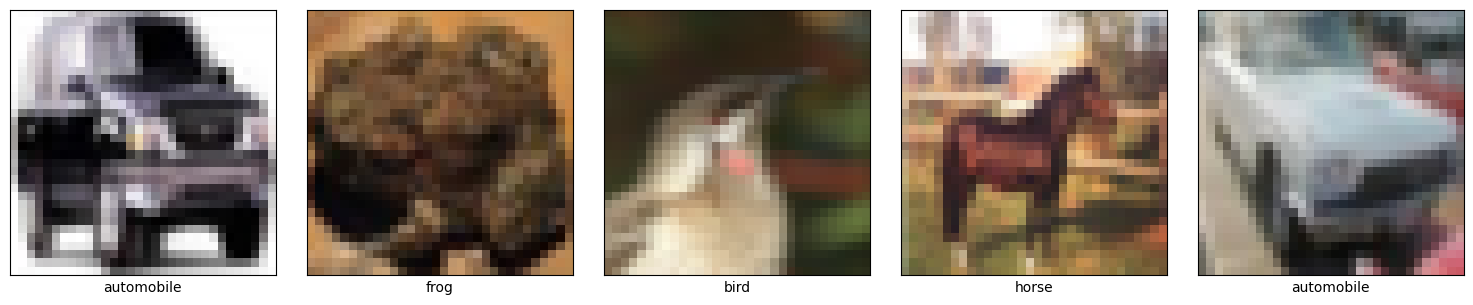

In [12]:
plot_samples(x_train, y_train, range(5))

#3. Baseline Model

##3.1. Define Baseline Architecture

In [13]:
def create_baseline():
    model = models.Sequential()
    model.add(layers.Input((32, 32, 3)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
    model.add(layers.MaxPooling2D((2, 2)))


    model.add(layers.Conv2D(64,(3,3),activation='relu',padding='same',kernel_initializer='he_normal'))
    model.add(layers.Conv2D(64,(3,3),activation='relu',padding='same',kernel_initializer='he_normal'))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(64,activation='relu',kernel_initializer='he_normal'))
    model.add(layers.Dense(10,activation='softmax'))

    model.compile(optimizer=tf.keras.optimizers.AdamW(
                            learning_rate=3e-4,
                            weight_decay=1e-4
                            ),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [14]:
temp_model = create_baseline()
temp_model.summary()
del temp_model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,378 (274.91 KB)

 Trainable params: 70,378 (274.91 KB)

 Non-trainable params: 0 (0.00 B)

## 3.2. Train Baseline with ResumableTrainer

In [15]:
baseline_trainer = ResumableTrainer(
    project_name="Cifar_10",
    experiment_name="baseline",
    model_fn=create_baseline,
    monitor = "val_loss",
    mode = "min",
    patience=5
)

 Checkpoint directory: /content/drive/MyDrive/Colab_Experiments/Cifar_10/baseline


In [16]:
baseline_trainer.fit((x_train, y_train), (x_val, y_val), epochs=30)


 No checkpoint found — starting from scratch

  Training from epoch 0 → 30

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2614 - loss: 1.9591
Epoch 1: val_loss improved from inf to 1.61720, saving model to /content/drive/MyDrive/Colab_Experiments/Cifar_10/baseline/baseline_best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.2615 - loss: 1.9590 - val_accuracy: 0.4014 - val_loss: 1.6172
Epoch 2/30
1400/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4123 - loss: 1.5890
Epoch 2: val_loss improved from 1.61720 to 1.46431, saving model to /content/drive/MyDrive/Colab_Experiments/Cifar_10/baseline/baseline_best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.4124 - loss: 1.5888 - val_accuracy: 0.4648 - val_loss: 1.4643
Epoch 3/30
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4667 - loss: 1.4582
Epoch 3: val_loss improved from 1.46431 to 1.39332, saving model to /content/drive/MyDrive/Colab_Experiments/Cifar_10/baseline/ba

## 3.3. Plot Training and Evaluate Baseline


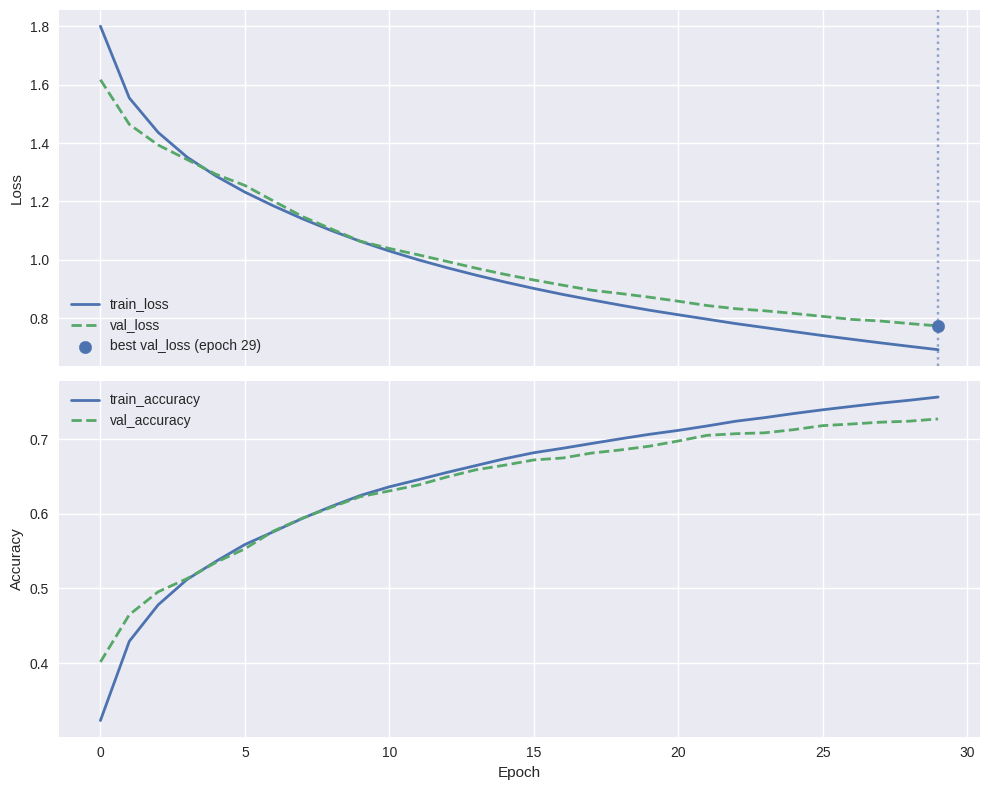

In [17]:
plot_training_curve(baseline_trainer.csv_log_path)

 Loading best model from /content/drive/MyDrive/Colab_Experiments/Cifar_10/baseline/baseline_best.keras
Test Loss:     0.7738
Test Accuracy: 0.7307

Classification Report:
              precision    recall  f1-score   support

    airplane       0.83      0.65      0.73      1000
  automobile       0.75      0.93      0.83      1000
        bird       0.61      0.67      0.63      1000
         cat       0.56      0.59      0.58      1000
        deer       0.71      0.67      0.69      1000
         dog       0.69      0.60      0.64      1000
        frog       0.76      0.78      0.77      1000
       horse       0.78      0.77      0.78      1000
        ship       0.76      0.92      0.84      1000
       truck       0.93      0.72      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000



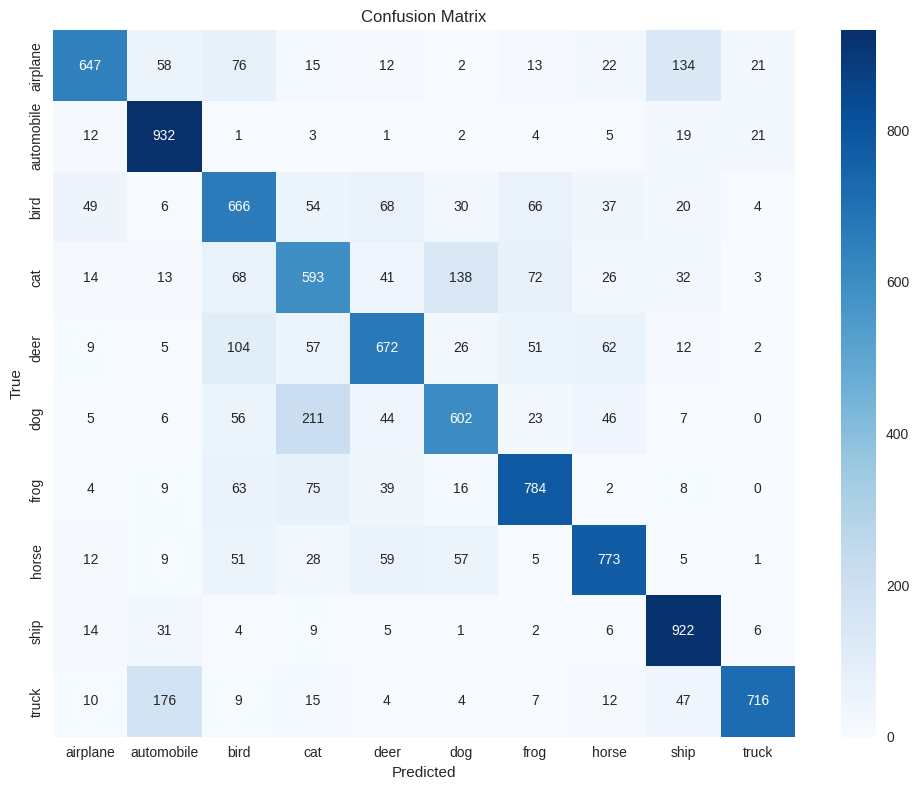

In [18]:
best_baseline = baseline_trainer.load_best_model()
evaluate_model(best_baseline, x_test, y_test, class_names)

In [19]:
tf.keras.backend.clear_session()
gc.collect()

0

#4. Model 1: Enhanced CNN with Batch Normalization and Dropout

##4.1. Define Model 1 Architecture

In [20]:
def conv_block(filters):
    return tf.keras.Sequential([
        layers.Conv2D(filters, 3, padding='same',
                      use_bias=False,
                      kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu')
    ])

In [21]:
def create_model1():
    model = models.Sequential()
    model.add(layers.Input((32, 32, 3)))

    # Block 1: 32 Filters

    model.add(conv_block(32))
    model.add(conv_block(32))

    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.2))

    # Block 2: 64 Filters

    model.add(conv_block(64))
    model.add(conv_block(64))

    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.3))

    # Block 3: 128 Filters
    model.add(conv_block(128))
    model.add(conv_block(128))

    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.4))

    # Classification Head
    model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Dense(128,kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(10, activation='softmax')) # 10 Classes

    # Compile
    model.compile(optimizer=tf.keras.optimizers.AdamW(
                            learning_rate=3e-4,
                            weight_decay=1e-4
                            ),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


In [22]:
temp_model = create_model1()
temp_model.summary()
del temp_model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 32)     │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 32, 32, 32)     │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 16, 16, 64)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 16, 16, 64)     │        37,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 8, 8, 128)      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 8, 8, 128)      │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,666 (1.17 MB)

 Trainable params: 305,514 (1.17 MB)

 Non-trainable params: 1,152 (4.50 KB)

## 4.2. Train Model 1 with ResumableTrainer

In [23]:
trainer_model1 = ResumableTrainer(
    project_name="Cifar_10",
    experiment_name="model_1",
    model_fn=create_model1,
    monitor = "val_loss",
    mode = "min",
    patience=7
)

 Checkpoint directory: /content/drive/MyDrive/Colab_Experiments/Cifar_10/model_1


In [24]:
trainer_model1.fit((x_train, y_train), (x_val, y_val), epochs=50)


 No checkpoint found — starting from scratch

  Training from epoch 0 → 50

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2631 - loss: 2.1259
Epoch 1: val_loss improved from inf to 1.59550, saving model to /content/drive/MyDrive/Colab_Experiments/Cifar_10/model_1/model_1_best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - accuracy: 0.2632 - loss: 2.1257 - val_accuracy: 0.4176 - val_loss: 1.5955
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4597 - loss: 1.4978
Epoch 2: val_loss improved from 1.59550 to 1.27816, saving model to /content/drive/MyDrive/Colab_Experiments/Cifar_10/model_1/model_1_best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4597 - loss: 1.4977 - val_accuracy: 0.5352 - val_loss: 1.2782
Epoch 3/50
1404/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5479 - loss: 1.2673
Epoch 3: val_loss improved from 1.27816 to 1.17188, saving model to /content/drive/MyDrive/Colab_Experiments/Cifar_10/model_1/model_

## 4.3. Plot Training and Evaluate Model 1

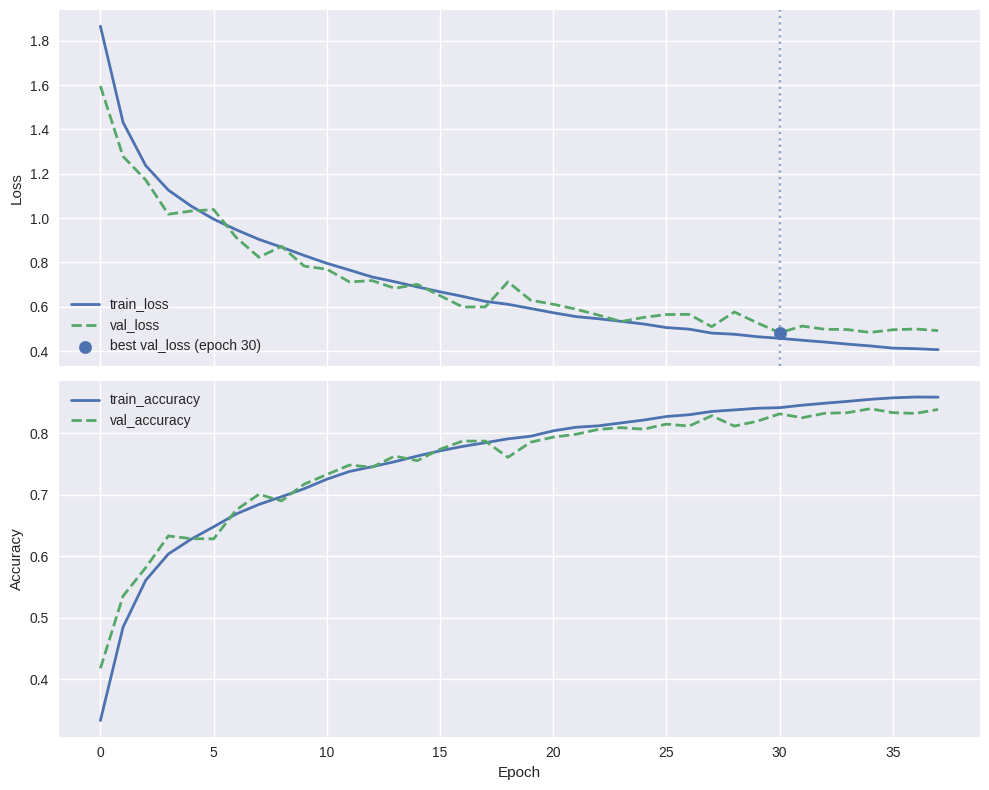

In [25]:
plot_training_curve(trainer_model1.csv_log_path)

 Loading best model from /content/drive/MyDrive/Colab_Experiments/Cifar_10/model_1/model_1_best.keras
Test Loss:     0.4918
Test Accuracy: 0.8319

Classification Report:
              precision    recall  f1-score   support

    airplane       0.87      0.81      0.84      1000
  automobile       0.94      0.91      0.92      1000
        bird       0.84      0.72      0.77      1000
         cat       0.71      0.65      0.68      1000
        deer       0.77      0.85      0.81      1000
         dog       0.73      0.79      0.76      1000
        frog       0.83      0.89      0.86      1000
       horse       0.87      0.86      0.87      1000
        ship       0.87      0.92      0.90      1000
       truck       0.89      0.92      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



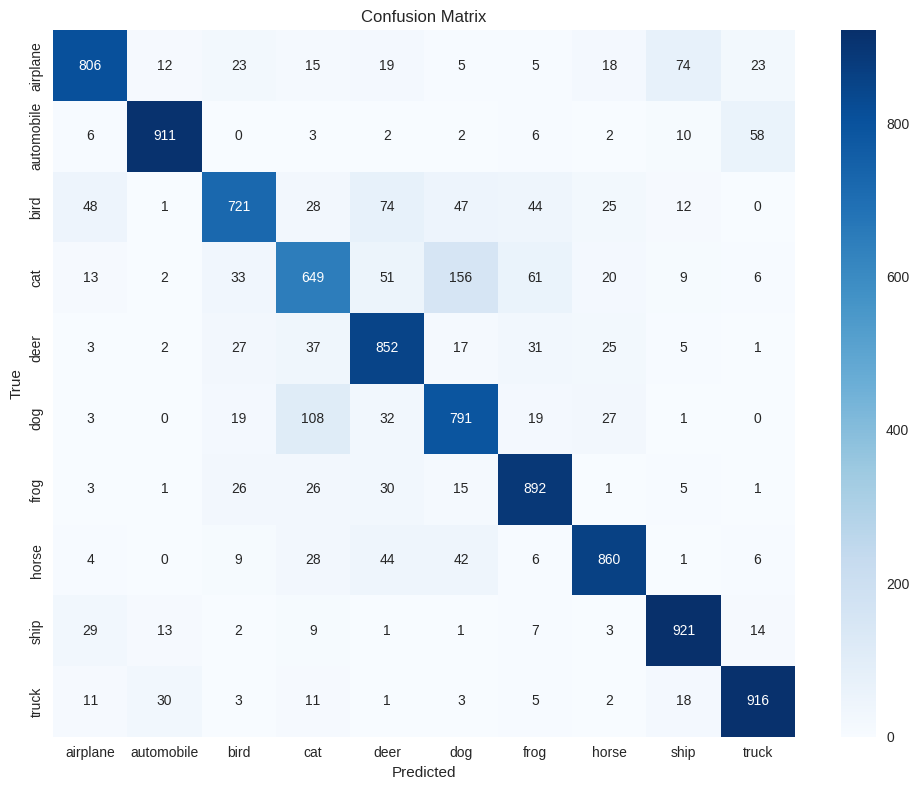

In [26]:
best_model_1 = trainer_model1.load_best_model()
evaluate_model(best_model_1, x_test, y_test, class_names)

In [27]:
tf.keras.backend.clear_session()
gc.collect()

0

#5. Model 2: Enhanced CNN with Data Augmentation and Deeper Architecture

##5.1. Define Model 2 Architecture with Data Augmentation

In [28]:
def create_model2():
    model = models.Sequential()
    model.add(layers.Input((32, 32, 3)))


    model.add(models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ] )
    )


    model.add(conv_block(32))

    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.2))

    model.add(conv_block(64))
    model.add(conv_block(64))

    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.3))

    model.add(conv_block(128))
    model.add(conv_block(128))

    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(conv_block(256))
    model.add(conv_block(256))

    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Dense(128,kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(10, activation='softmax'))

    model.compile(tf.keras.optimizers.AdamW(
                  learning_rate=3e-4,
                  weight_decay=1e-4
                  ),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [29]:
temp_model = create_model2()
temp_model.summary()
del temp_model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 32, 32, 32)     │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 16, 16, 64)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 16, 16, 64)     │        37,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 8, 8, 128)      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 8, 8, 128)      │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 4, 4, 256)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 4, 4, 256)      │       590,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,490 (4.58 MB)

 Trainable params: 1,198,378 (4.57 MB)

 Non-trainable params: 2,112 (8.25 KB)

## 5.2 Train Model 2 with ResumableTrainer

In [30]:
trainer_model2 = ResumableTrainer(
    project_name="Cifar_10",
    experiment_name="model_2",
    model_fn=create_model2,
    monitor = "val_loss",
    mode = "min",
    patience=15
)

 Checkpoint directory: /content/drive/MyDrive/Colab_Experiments/Cifar_10/model_2


In [31]:
trainer_model2.fit((x_train, y_train), (x_val, y_val), epochs=80)


 No checkpoint found — starting from scratch

  Training from epoch 0 → 80

Epoch 1/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2596 - loss: 2.0905
Epoch 1: val_loss improved from inf to 1.67835, saving model to /content/drive/MyDrive/Colab_Experiments/Cifar_10/model_2/model_2_best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.2597 - loss: 2.0904 - val_accuracy: 0.4162 - val_loss: 1.6783
Epoch 2/80
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4152 - loss: 1.6050
Epoch 2: val_loss did not improve from 1.67835
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.4152 - loss: 1.6049 - val_accuracy: 0.4394 - val_loss: 1.7433
Epoch 3/80
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4791 - loss: 1.4392
Epoch 3: val_loss improved from 1.67835 to 1.47980, saving model to /content/drive/MyDrive/Colab_Experiments/Cifar_10/model_2/model_2_best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.4791 - loss: 1.4392 - 

##5.3 Plot training and Evaluate Model 2

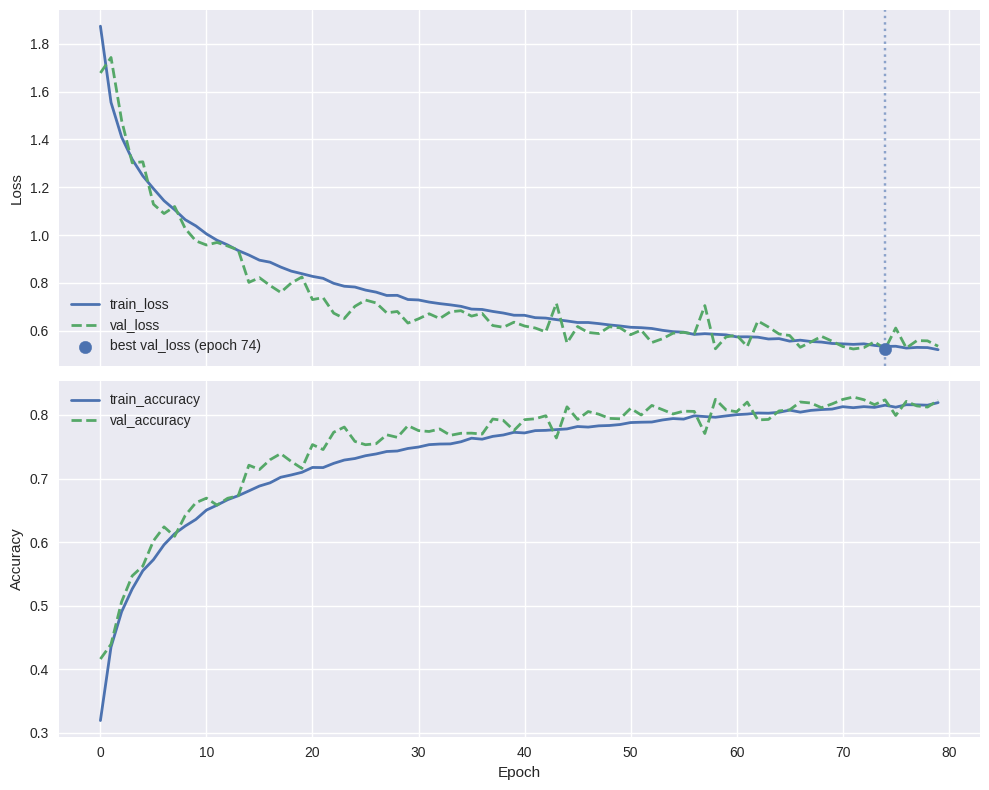

In [32]:
plot_training_curve(trainer_model2.csv_log_path)

 Loading best model from /content/drive/MyDrive/Colab_Experiments/Cifar_10/model_2/model_2_best.keras
Test Loss:     0.5221
Test Accuracy: 0.8245

Classification Report:
              precision    recall  f1-score   support

    airplane       0.82      0.88      0.85      1000
  automobile       0.90      0.91      0.91      1000
        bird       0.85      0.73      0.78      1000
         cat       0.79      0.59      0.68      1000
        deer       0.83      0.77      0.80      1000
         dog       0.79      0.76      0.77      1000
        frog       0.78      0.91      0.84      1000
       horse       0.79      0.92      0.85      1000
        ship       0.90      0.86      0.88      1000
       truck       0.80      0.92      0.86      1000

    accuracy                           0.82     10000
   macro avg       0.83      0.82      0.82     10000
weighted avg       0.83      0.82      0.82     10000



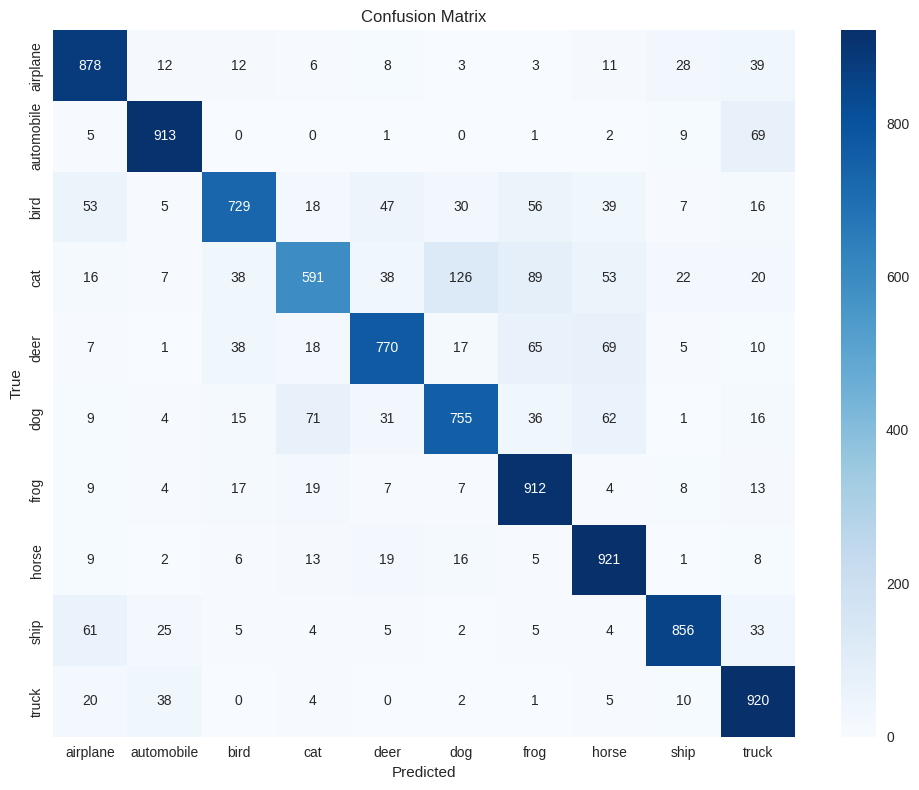

In [33]:
best_model_2 = trainer_model2.load_best_model()
evaluate_model(best_model_2, x_test, y_test, class_names)

In [34]:
tf.keras.backend.clear_session()
gc.collect()

0